# Lecture 5 - Beyond Matplotlib

seaborn, plotly, wordcloud, venn diagrams

In [50]:
import importlib

import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go
from wordcloud import WordCloud
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

## seaborn
built on matplotlib, easier for multi-variable plots

In [51]:
# sample dataset included with seaborn
tips = sns.load_dataset("tips")
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: xlabel='total_bill', ylabel='tip'>

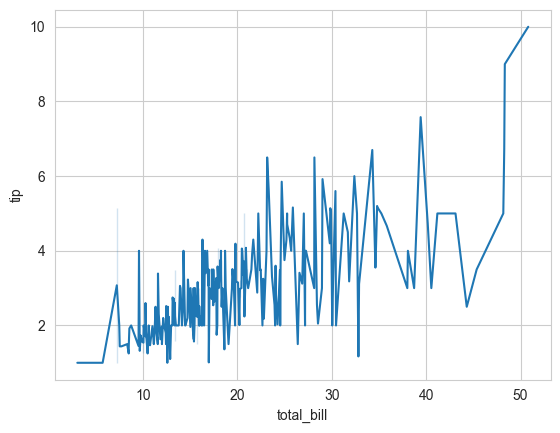

In [52]:
# basic line plot
sns.lineplot(data=tips, x='total_bill', y='tip')

<Axes: xlabel='total_bill', ylabel='tip'>

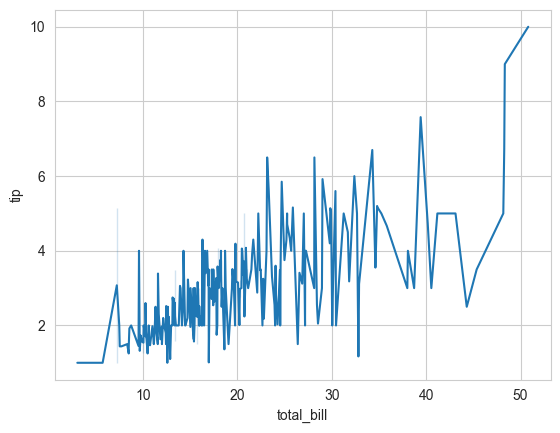

In [53]:
# set style
sns.set_style('whitegrid')
sns.lineplot(data=tips, x='total_bill', y='tip')

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

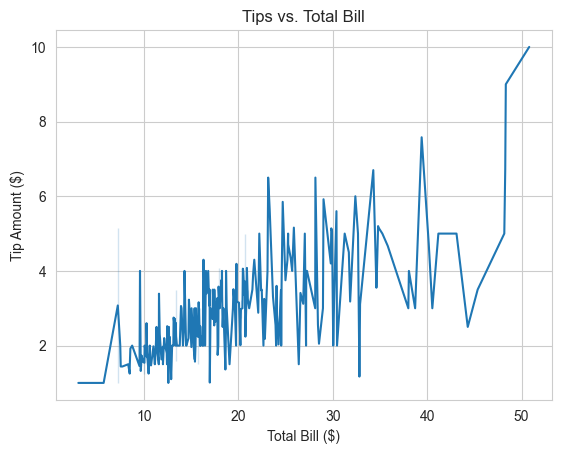

In [54]:
# add titles/labels with set()
tipgraph = sns.lineplot(data=tips, x='total_bill', y='tip')
tipgraph.set(title='Tips vs. Total Bill',
             xlabel='Total Bill ($)',
             ylabel='Tip Amount ($)')

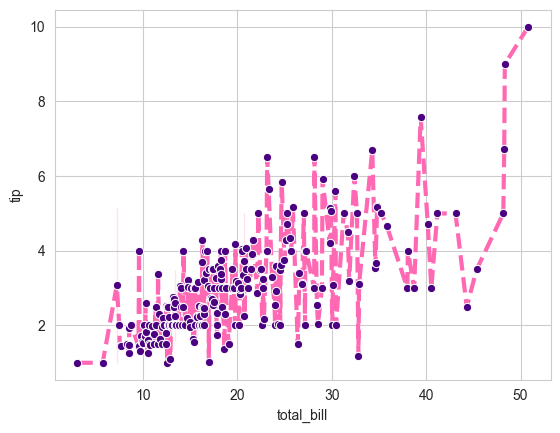

In [55]:
# customize aesthetics
tipgraph = sns.lineplot(data=tips, x='total_bill', y='tip',
                        color='hotpink',
                        linestyle='--',
                        linewidth=3,
                        marker='o',
                        markerfacecolor='indigo')

## hue and style
map extra variables to color/shape

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

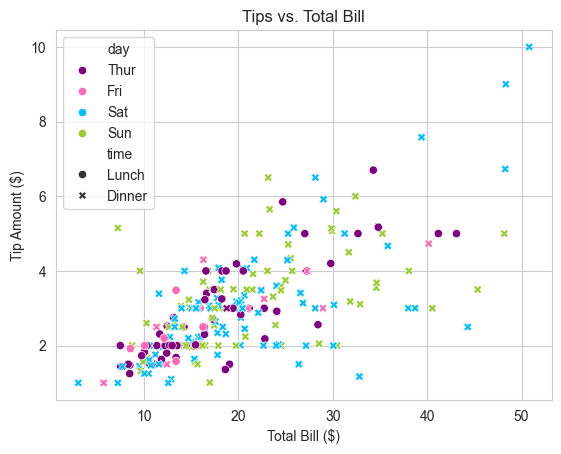

In [56]:
# hue = color by category, style = shape by category
tipgraph = sns.scatterplot(data=tips, x='total_bill', y='tip',
                           style='time',
                           hue='day',
                           palette=['purple', 'hotpink', 'deepskyblue', 'yellowgreen'])

tipgraph.set(title='Tips vs. Total Bill',
             xlabel='Total Bill ($)',
             ylabel='Tip Amount ($)')

## pairplot
all numeric variables vs each other - good for exploring

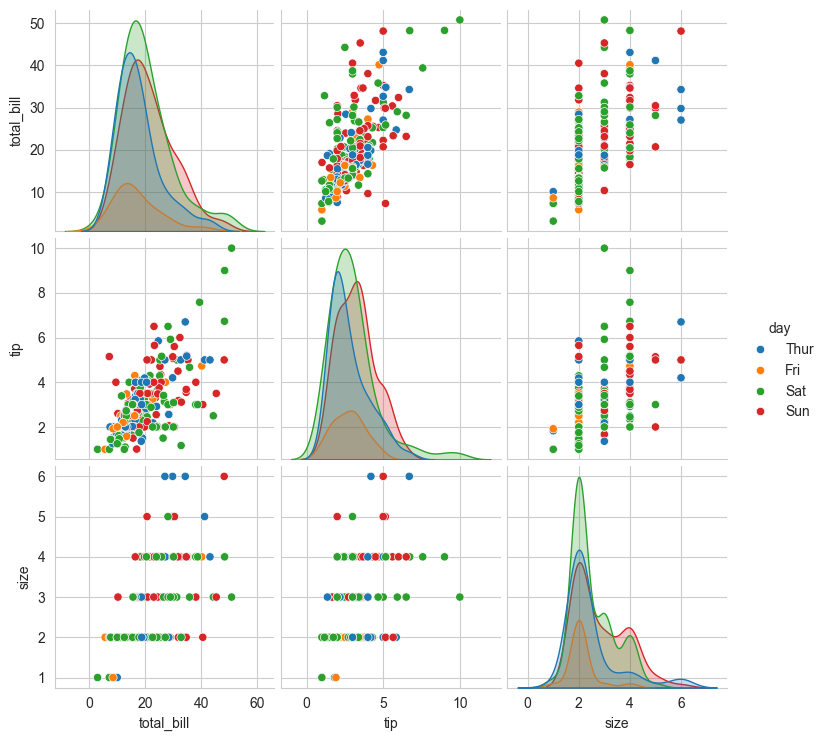

In [57]:
sns.pairplot(data=tips, hue='day')

## relplot
separate panels for each category level

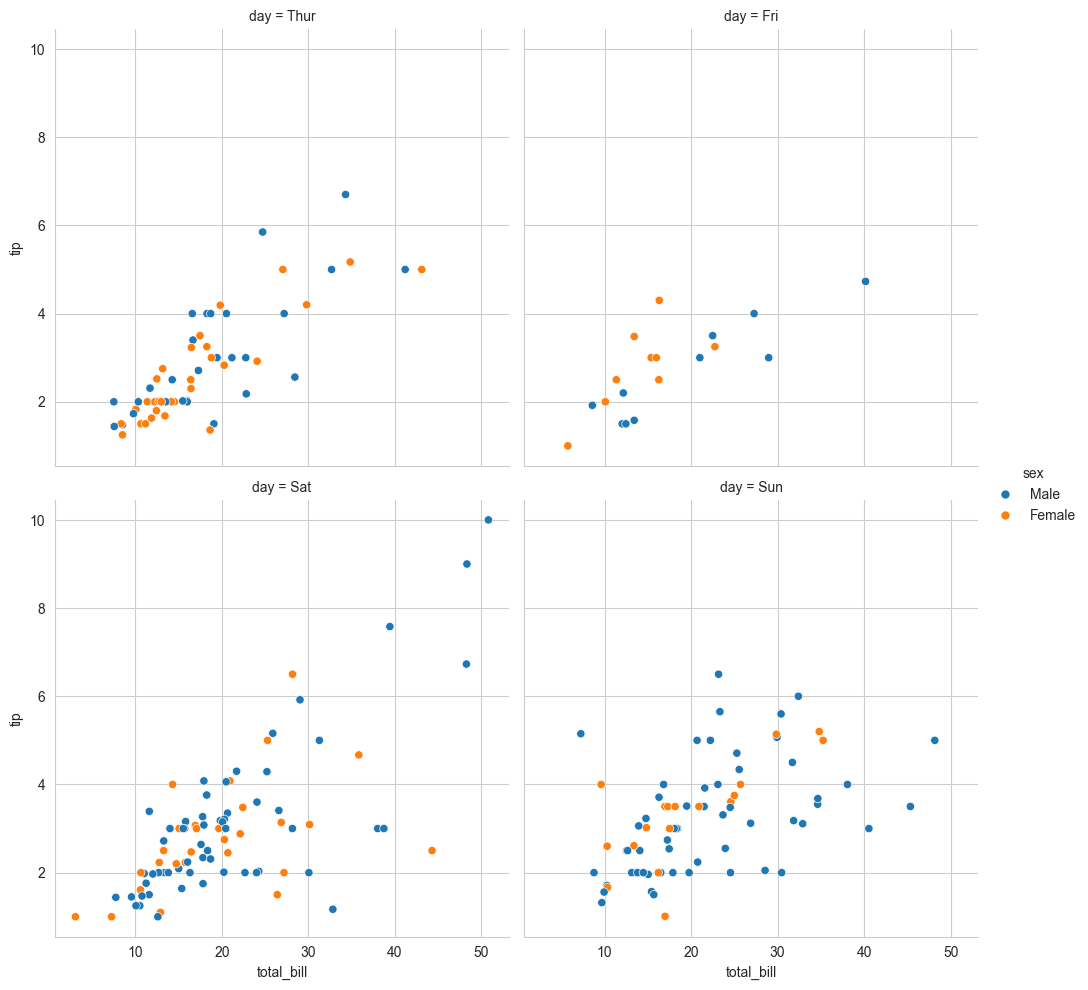

In [58]:
# col = split into separate plots by day
sns.relplot(data=tips, x="total_bill", y="tip",
            hue="sex",
            col="day",
            kind="scatter",
            col_wrap=2)  # 2 columns per row

## plotly
interactive plots - can zoom, pan, hover

In [59]:
x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])

In [60]:
# basic bar chart
graph = go.Figure()
graph.add_trace(go.Bar(x=x1, y=y1))

In [61]:
# add title and axis labels
graph = go.Figure()
graph.add_trace(go.Bar(x=x1, y=y1))
graph.update_layout(title="Pirate Scores",
                    xaxis_title="Pirates",
                    yaxis_title="Score")

In [62]:
# scatter with custom markers
# line = stroke around markers
graph = go.Figure()
graph.add_trace(go.Scatter(x=x1, y=y1, mode='markers',
    marker=dict(
        size=15,
        color='hotpink',
        opacity=1,
        line=dict(width=5, color='purple')
    )))

graph.update_layout(title='Pirate Plot',
                    xaxis_title='Pirates',
                    yaxis_title='Scores',
                    width=500, height=500)

In [63]:
# save plotly graph as HTML for web embedding
# graph.write_html("pirate_plot.html")

## wordcloud
text visualization - word size = frequency

In [64]:
# load sample text data
df = pd.read_csv("https://cdn.jsdelivr.net/gh/prasertcbs/basic-dataset@master/movie_quotes.csv",
                 on_bad_lines='skip')
df

,quote,movie,type,year
0,"Do, or do not. There is no try.",Star Wars: Episode V - The Empire Strikes Back,movie,1890
1,Listen to them. Children of the night. What mu...,Dracula,movie,1931
2,It's alive! It's alive!,Frankenstein,movie,1931
3,"Oh, no, it wasn't the airplanes. It was Beauty...",King Kong,movie,1933
4,"Magic Mirror on the wall, who is the fairest o...",Snow White and the Seven Dwarves,movie,1937
...,...,...,...,...
727,I didn't know if you were lost. Stick with me....,Us,movie,2019
728,This guy's awesome! He's holding his own while...,Dragon Ball Super: Broly,movie,2019
729,"Murder is murder, it don’t matter who you are.",Black and Blue,movie,2019
730,You know what a lion is? A lion is a strong an...,Between Two Ferns: The Movie,movie,2019


(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

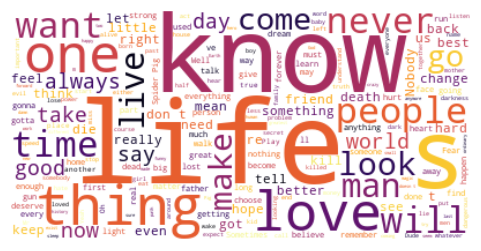

In [65]:
# join all quotes into one string
text = " ".join(each for each in df.quote)

# generate wordcloud
wordcloud = WordCloud(background_color="white",
                      colormap='inferno').generate(text)

# display with matplotlib
fig, ax = plt.subplots(figsize=(7, 3))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis("off")

## venn diagrams
show set overlap

In [66]:
A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

/Users/mcowan38/Documents/GitHub/DSI/visualization/.venv/lib/python3.12/site-packages/matplotlib_venn/_util.py:32: UserWarning:

venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.



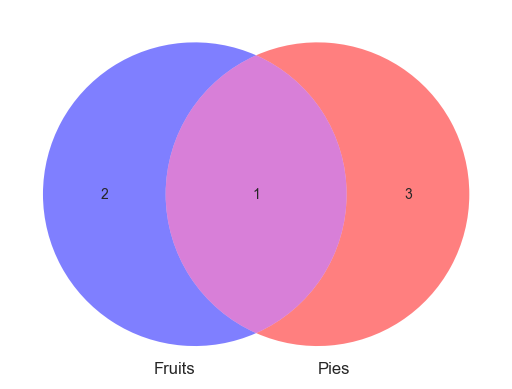

In [67]:
# basic venn
diagram = venn2_unweighted([A, B],
                           set_labels=('Fruits', 'Pies'),
                           set_colors=("blue", "red"),
                           alpha=0.5)
plt.show()

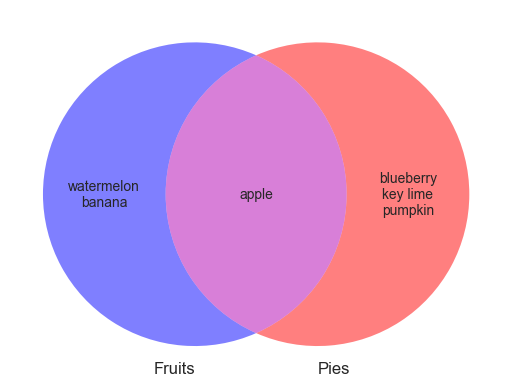

In [68]:
# show actual elements instead of counts
# region IDs: 10 = A only, 11 = both, 01 = B only
diagram = venn2_unweighted([A, B],
                           set_labels=('Fruits', 'Pies'),
                           set_colors=("blue", "red"),
                           alpha=0.5)

diagram.get_label_by_id("10").set_text("\n".join(A - B))
diagram.get_label_by_id("11").set_text("\n".join(A & B))
diagram.get_label_by_id("01").set_text("\n".join(B - A))

plt.show()